# Modul 13 — NLP untuk Analisis Teks Bisnis
## Convergeni Data Consulting (CDC) — Klien: Talenta Prima

Notebook ini menjalankan seluruh pipeline NLP Modul 13: stemming Sastrawi,
TF-IDF, model sentimen 70 ulasan nyata, dan uji keterbatasan negasi.

## Data: 70 Ulasan Talenta Prima (35 Positif, 35 Negatif)

In [1]:
import pandas as pd

ulasan_positif = ['Agennya sangat membantu dan ramah, masalah saya selesai dalam 5 menit', 'Responnya cepat sekali, saya senang dilayani dengan baik', 'Terima kasih banyak, CS-nya sabar menjelaskan sampai saya paham', 'Pelayanan hari ini memuaskan, agen menjawab semua pertanyaan saya', 'Saya kagum dengan kecepatan respon tim customer service', 'Agennya sopan dan profesional, sangat membantu proses saya', 'Keluhan saya ditangani dengan cepat dan tuntas, terima kasih', 'Pengalaman menghubungi CS kali ini sangat menyenangkan', 'Petugasnya ramah dan menjelaskan dengan sangat jelas', 'Saya puas dengan solusi yang diberikan agen customer service', 'Prosesnya lancar, agennya tanggap dan komunikatif', 'Sangat membantu, masalah rumit saya bisa selesai dengan cepat', 'CS-nya baik hati dan sabar mendengarkan keluhan saya', 'Saya senang, agennya proaktif menawarkan solusi terbaik', 'Pelayanan cepat tanggap, tidak perlu menunggu lama', 'Agennya sangat kompeten dan mengerti masalah saya', 'Terima kasih atas bantuannya, semua berjalan lancar', 'Saya terkesan dengan keramahan dan kesabaran tim CS', 'Responnya sigap, keluhan saya langsung ditindaklanjuti', 'Pelayanan hari ini luar biasa, agennya profesional', 'Saya puas sekali, tim CS sangat kooperatif', 'Prosesnya cepat, agennya ramah sejak awal percakapan', 'Masalah saya diselesaikan dengan sangat memuaskan', 'Agennya perhatian dan detail menjelaskan setiap langkah', 'Saya sangat senang dengan pelayanan yang diberikan', 'CS-nya membantu tanpa harus saya jelaskan berulang kali', 'Pengalaman terbaik saya menghubungi layanan pelanggan', 'Agennya cekatan dan menyelesaikan masalah dengan tepat', 'Terima kasih, tim CS sangat responsif dan membantu', 'Saya puas dengan kecepatan dan kualitas pelayanannya', 'Petugas customer service sangat ramah dan informatif', 'Keluhan saya ditanggapi dengan serius dan cepat', 'Agennya luar biasa sabar menjelaskan sampai saya mengerti', 'Saya merasa dihargai sebagai pelanggan, pelayanannya bagus', 'Prosesnya mudah dan agennya sangat membantu sepanjang percakapan']

ulasan_negatif = ['Saya kecewa berat, sudah menunggu lebih dari satu jam tidak ada respon', 'Agennya kasar dan tidak sabar menjawab pertanyaan saya', 'Masalah saya belum juga selesai setelah tiga kali menghubungi CS', 'Pelayanannya sangat lambat, saya harus menunggu terlalu lama', 'Saya kecewa, agennya tidak mengerti masalah yang saya sampaikan', 'CS-nya tidak ramah dan terkesan terburu-buru', 'Keluhan saya diabaikan begitu saja tanpa penjelasan', 'Pengalaman menghubungi CS kali ini sangat mengecewakan', 'Petugasnya tidak sopan dan jawabannya berbelit-belit', 'Saya tidak puas, solusi yang diberikan tidak menyelesaikan masalah', 'Prosesnya berbelit, agennya tidak komunikatif sama sekali', 'Sangat mengecewakan, masalah sederhana saja tidak bisa diselesaikan', 'CS-nya terkesan malas menjawab pertanyaan saya', 'Saya kesal, agennya tidak menawarkan solusi apa pun', 'Pelayanan lambat sekali, saya menunggu tanpa kejelasan', 'Agennya kurang kompeten dan tidak paham masalah saya', 'Tidak ada tindak lanjut sama sekali dari keluhan saya', 'Saya kecewa dengan sikap kasar tim customer service', 'Responnya lambat, keluhan saya baru ditanggapi setelah berhari-hari', 'Pelayanan hari ini buruk sekali, agennya tidak profesional', 'Saya tidak puas, tim CS terkesan tidak peduli', 'Prosesnya lama sekali, agennya kurang ramah sejak awal', 'Masalah saya tidak diselesaikan dengan memuaskan', 'Agennya cuek dan tidak detail menjelaskan apa pun', 'Saya sangat kecewa dengan pelayanan yang diberikan', 'CS-nya menyuruh saya menjelaskan berulang kali tanpa hasil', 'Pengalaman terburuk saya menghubungi layanan pelanggan', 'Agennya lambat dan tidak menyelesaikan masalah dengan tepat', 'Sayangnya, tim CS tidak responsif dan tidak membantu', 'Saya kecewa dengan kelambatan dan kualitas pelayanannya', 'Petugas customer service tidak ramah dan tidak informatif', 'Keluhan saya ditanggapi dengan lambat dan tidak serius', 'Agennya tidak sabar dan terkesan ingin cepat mengakhiri percakapan', 'Saya merasa diabaikan sebagai pelanggan, pelayanannya buruk', 'Prosesnya sulit dan agennya tidak membantu sepanjang percakapan']

df = pd.DataFrame(
    [(t, 1) for t in ulasan_positif] + [(t, 0) for t in ulasan_negatif],
    columns=["teks", "sentimen"]
)
print(df.shape)
print(df["sentimen"].value_counts())

(70, 2)
sentimen
1    35
0    35
Name: count, dtype: int64


## Stemming dan Preprocessing

In [2]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

stemmer = StemmerFactory().create_stemmer()
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()

def bersihkan_teks(teks):
    teks = teks.lower()
    teks = stopword_remover.remove(teks)
    teks = stemmer.stem(teks)
    return teks

contoh = "Agennya sangat membantu dan ramah, masalah saya selesai dalam 5 menit"
print("Asli  :", contoh)
print("Bersih:", bersihkan_teks(contoh))

df["teks_bersih"] = df["teks"].apply(bersihkan_teks)

Asli  : Agennya sangat membantu dan ramah, masalah saya selesai dalam 5 menit
Bersih: agen sangat bantu ramah masalah selesai 5 menit


## Model TF-IDF + Logistic Regression

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    df["teks_bersih"], df["sentimen"], test_size=0.25, random_state=42, stratify=df["sentimen"]
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"Jumlah kata unik (vocabulary): {len(vectorizer.vocabulary_)}")

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
pred = model.predict(X_test_tfidf)

akurasi = accuracy_score(y_test, pred)
print(f"Akurasi: {akurasi:.4f}")
print(classification_report(y_test, pred))

Train: 52, Test: 18
Jumlah kata unik (vocabulary): 109
Akurasi: 0.5556
              precision    recall  f1-score   support

           0       0.57      0.44      0.50         9
           1       0.55      0.67      0.60         9

    accuracy                           0.56        18
   macro avg       0.56      0.56      0.55        18
weighted avg       0.56      0.56      0.55        18



## Visualisasi 1: Confusion Matrix Data Uji (Asset Baru)

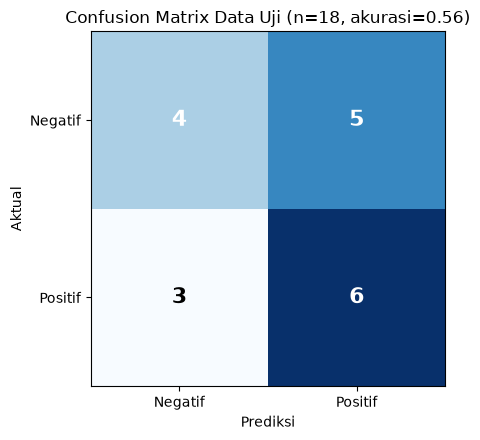

In [4]:
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=16, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Negatif", "Positif"]); ax.set_yticklabels(["Negatif", "Positif"])
ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")
ax.set_title(f"Confusion Matrix Data Uji (n={len(y_test)}, akurasi={akurasi:.2f})")
plt.tight_layout()
plt.savefig("modul13_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Uji Keterbatasan Negasi

In [5]:
kalimat_baru = [
    "Pelayanannya sangat lambat dan agennya tidak sopan",
    "Saya senang sekali, agennya sangat membantu",
    "Agennya tidak lambat",
]
kalimat_bersih = [bersihkan_teks(k) for k in kalimat_baru]
for asli, bersih in zip(kalimat_baru, kalimat_bersih):
    print(f"'{asli}' -> bersih: '{bersih}'")

pred_baru = model.predict(vectorizer.transform(kalimat_bersih))
proba_baru = model.predict_proba(vectorizer.transform(kalimat_bersih))
print()
for k, p, pr in zip(kalimat_baru, pred_baru, proba_baru):
    label = "POSITIF" if p == 1 else "NEGATIF"
    print(f"'{k}' -> {label} (prob positif={pr[1]:.3f})")

'Pelayanannya sangat lambat dan agennya tidak sopan' -> bersih: 'layan sangat lambat agen sopan'
'Saya senang sekali, agennya sangat membantu' -> bersih: 'senang sekali agen sangat bantu'
'Agennya tidak lambat' -> bersih: 'agen lambat'

'Pelayanannya sangat lambat dan agennya tidak sopan' -> NEGATIF (prob positif=0.464)
'Saya senang sekali, agennya sangat membantu' -> POSITIF (prob positif=0.643)
'Agennya tidak lambat' -> NEGATIF (prob positif=0.372)


## Visualisasi 2: Skor TF-IDF Kata Kunci Negasi (Asset Baru)

'Agennya tidak lambat' -> bersih: 'agen lambat'
'tidak' ada di vocabulary TF-IDF: True


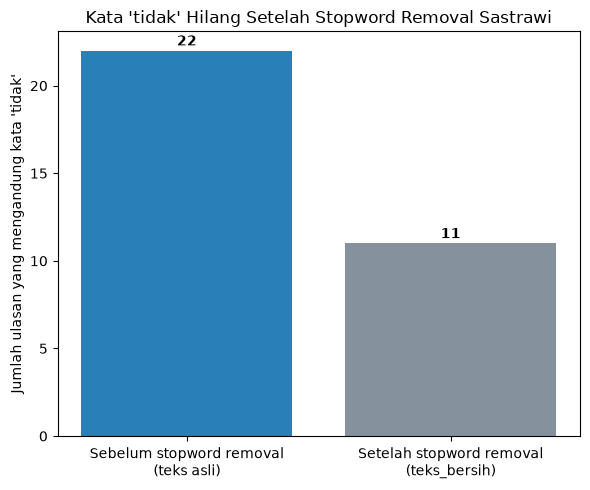

In [6]:
kalimat_negasi_tes = "Agennya tidak lambat"
bersih_negasi = bersihkan_teks(kalimat_negasi_tes)
print(f"'{kalimat_negasi_tes}' -> bersih: '{bersih_negasi}'")
print(f"'tidak' ada di vocabulary TF-IDF: {'tidak' in vectorizer.vocabulary_}")

# Hitung berapa kali "tidak" MUNCUL vs HILANG setelah stopword removal di seluruh 70 ulasan
mengandung_tidak_asli = df["teks"].str.lower().str.contains(r"\btidak\b").sum()
mengandung_tidak_bersih = df["teks_bersih"].str.contains(r"\btidak\b").sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Sebelum stopword removal\n(teks asli)", "Setelah stopword removal\n(teks_bersih)"],
       [mengandung_tidak_asli, mengandung_tidak_bersih], color=["#2980B9", "#85929E"])
ax.set_ylabel("Jumlah ulasan yang mengandung kata 'tidak'")
ax.set_title("Kata 'tidak' Hilang Setelah Stopword Removal Sastrawi")
for i, v in enumerate([mengandung_tidak_asli, mengandung_tidak_bersih]):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("modul13_kata_tidak_hilang.png", dpi=150, bbox_inches="tight")
plt.show()